In [114]:
import numpy as np
import pandas as pd


In [115]:
df=pd.read_csv(r'D:\Enterprise_ITSM_AI\data\raw\itsm_cleaned_dataset.csv')

In [116]:
df.columns

Index(['number', 'incident_state', 'active', 'reassignment_count',
       'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by',
       'opened_at', 'sys_updated_by', 'sys_updated_at', 'contact_type',
       'location', 'category', 'subcategory', 'u_symptom', 'impact', 'urgency',
       'priority', 'assignment_group', 'knowledge', 'u_priority_confirmation',
       'notify', 'closed_code', 'resolved_by', 'resolved_at', 'opened_hour',
       'opened_day_of_week', 'opened_month', 'is_weekend'],
      dtype='object')

Checking the category order for building preprocessing pipeline

In [117]:
df['impact'].nunique()

3

In [118]:
df['urgency'].nunique()

3

In [119]:
df['priority'].nunique()

4

In [120]:
df['incident_state'].value_counts()

incident_state
Active                38716
New                   36407
Resolved              25751
Closed                24985
Awaiting User Info    14642
Awaiting Vendor         707
Awaiting Problem        461
Awaiting Evidence        38
-100                      5
Name: count, dtype: int64

In [121]:
df['reassignment_count'].value_counts()


reassignment_count
0     69876
1     37104
2     15097
3      8274
4      4614
5      2595
6      1447
7       985
8       574
9       365
10      285
11      174
12      108
13       61
14       45
15       21
17       16
20       16
16       13
18       13
22        9
19        8
21        3
27        3
23        2
26        2
24        1
25        1
Name: count, dtype: int64

In [122]:
df['reopen_count'].value_counts()

reopen_count
0    139398
1      1918
2       190
3       107
4        48
5        24
6        18
7         5
8         4
Name: count, dtype: int64

In [123]:
df['opened_by'].nunique()


207

In [124]:
df['sys_mod_count'].describe()

count    141712.000000
mean          5.080946
std           7.680652
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max         129.000000
Name: sys_mod_count, dtype: float64

In [125]:
df['caller_id'].nunique()

5244

creating some features with opened at

In [126]:
df['opened_at'].head(5)

0    2016-02-29 01:16:00
1    2016-02-29 01:16:00
2    2016-02-29 01:16:00
3    2016-02-29 01:16:00
4    2016-02-29 04:40:00
Name: opened_at, dtype: object

In [127]:
df['opened_at']=pd.to_datetime(df['opened_at'])

In [128]:
df['opened_hour']=df['opened_at'].dt.hour

In [129]:
df['opened_day_of_week']=df['opened_at'].dt.day_of_week

In [130]:
df['opened_month']=df['opened_at'].dt.month

In [131]:
df['is_weekend']=df['opened_at'].dt.weekday.isin([5,6])

In [132]:
df['is_weekend'].nunique()

2

Creating separate dataset for category prediction

Rare Categories with extremely low frequency were removed because they do not provide enough examples for the model to learn meaningful patterns

In [133]:
df['category'].value_counts()

category
Category 26    18453
Category 42    15977
Category 53    15968
Category 46    13324
Category 23     7779
Category 9      7365
Category 32     7273
Category 37     6584
Category 57     6532
Category 20     5506
Category 61     5168
Category 24     4561
Category 34     3946
Category 40     3760
Category 45     3619
Category 51     2390
Category 28     2256
Category 35     2037
Category 44     1798
Category 19     1592
Category 13      994
Category 43      858
Category 55      801
Category 17      512
Category 22      420
Category 56      322
Category 38      290
Category 8       264
Category 7       207
Category 33      160
Category 54      139
Category 50       93
Category 31       92
Category 63       78
Category 2        77
Category 21       69
Category 47       50
Category 59       42
Category 41       36
Category 29       32
Category 5        31
Category 25       30
Category 62       25
Category 10       24
Category 4        22
Category 52       16
Category 30       15
Cate

In [134]:
rare_categories=['Category 27','Category 49','Category 36','Category 3','Category 14','Category 15','Category 12']
df=df[~df['category'].isin(rare_categories)]

In [135]:
df['category'].value_counts().tail()

category
Category 30    15
Category 48    10
Category 16     7
Category 6      7
Category 58     5
Name: count, dtype: int64

In [136]:
#Features
X=df[['contact_type','location','u_symptom','impact','urgency','knowledge','notify','opened_hour','opened_day_of_week','opened_month','is_weekend']]
#Target Variable
y=df['category']

In [137]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

Checking the category status of each feature for preprocessing

In [138]:
df['contact_type'].describe()

count     141694
unique         5
top        Phone
freq      140447
Name: contact_type, dtype: object

In [139]:
df['location'].describe()

count           141620
unique             224
top       Location 204
freq             31688
Name: location, dtype: object

In [140]:
df['u_symptom'].describe()

count          108735
unique            524
top       Symptom 491
freq            51983
Name: u_symptom, dtype: object

In [141]:
df['knowledge'].describe()

count     141694
unique         2
top        False
freq      116338
Name: knowledge, dtype: object

In [142]:
df['notify'].describe()

count            141694
unique                2
top       Do Not Notify
freq             141575
Name: notify, dtype: object

In [143]:
df['impact'].value_counts().tail()

impact
2 - Medium    134317
3 - Low         3886
1 - High        3491
Name: count, dtype: int64

In [144]:
df['urgency'].value_counts().tail()

urgency
2 - Medium    134076
1 - High        4020
3 - Low         3598
Name: count, dtype: int64

In [145]:
X.dtypes

contact_type          object
location              object
u_symptom             object
impact                object
urgency               object
knowledge               bool
notify                object
opened_hour            int32
opened_day_of_week     int32
opened_month           int32
is_weekend              bool
dtype: object

In [146]:
print(df['impact'].unique())
print(df['urgency'].unique())

['2 - Medium' '1 - High' '3 - Low']
['2 - Medium' '3 - Low' '1 - High']


importing required preprocessing techniques and pipeline

In [147]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [148]:
import xgboost
from xgboost import XGBClassifier

As the category feature is highly imbalanced i applied stratify=y which ensures that the class distinction of the target variable(category) remains the same in both the training and test sets.

In [149]:
X_train,X_test,y_encoded_train,y_encoded_test=train_test_split(X,y_encoded,test_size=0.20,random_state=42,stratify=y)

ValueError: Input contains NaN

Applying Preprocessing Techniques using sklearn column transformer class which maintains seamless compatability with sklearn pipeline

In [ ]:
preprocessing_data=ColumnTransformer(
    transformers=[
        (
            'trf1',
            OrdinalEncoder(categories=[['1 - High','2 - Medium','3 - Low'],['1 - High','2 - Medium','3 - Low']]),
            ['impact','urgency']
        ),
        (
            'trf2',
            OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'),
            ['contact_type','location','u_symptom','notify','opened_day_of_week']
        )],
    remainder='passthrough')




Passing the preprocessing data for training

fit()-the preprocessor learns from the training data,it learns mappings like 1 - High -> 0,2 - Medium -> 1,3 - Low -> 2
fit().transform()-After learning,the preprocessor directly transforms the training data

In [ ]:
preprocessing_data.fit_transform(X_train)

array([[1.0, 1.0, 0.0, ..., 16, 3, False],
       [1.0, 1.0, 0.0, ..., 9, 5, False],
       [1.0, 1.0, 0.0, ..., 9, 4, False],
       ...,
       [1.0, 1.0, 0.0, ..., 5, 5, True],
       [1.0, 1.0, 0.0, ..., 14, 3, False],
       [1.0, 1.0, 0.0, ..., 19, 3, True]], dtype=object)

transform() is applied consistently to both training and test data, preventing data leakage.

In [ ]:
preprocessing_data.transform(X_test)

c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([[1.0, 1.0, 0.0, ..., 7, 3, False],
       [1.0, 1.0, 0.0, ..., 18, 5, False],
       [1.0, 1.0, 0.0, ..., 13, 3, False],
       ...,
       [1.0, 1.0, 0.0, ..., 20, 5, False],
       [1.0, 1.0, 0.0, ..., 16, 4, False],
       [1.0, 1.0, 0.0, ..., 10, 5, False]], dtype=object)

Preprocessing the features and initializing the models

Applying ML pipeline for easy data inconsistent handling and deploys without errors.Using ML pipeline we can reuse the same preprocessing framework for all the models

In [ ]:
preprocessing_data=ColumnTransformer(
    transformers=[
        (
            'trf1',
            OrdinalEncoder(categories=[['1 - High','2 - Medium','3 - Low'],['1 - High','2 - Medium','3 - Low']]),
            ['impact','urgency']
        ),
        (
            'trf2',
            OneHotEncoder(handle_unknown='ignore'),
            ['contact_type','location','u_symptom','notify','opened_day_of_week']
        )],
    remainder='passthrough')
#creating multiple pipeline for different models
dt_pipeline=Pipeline([
    ('preprocessor',preprocessing_data),
    ('model',DecisionTreeClassifier(max_depth=3,min_samples_leaf=20,min_samples_split=10,random_state=42))
])

rf_pipeline=Pipeline([
    ('preprocessor',preprocessing_data),
    ('model',RandomForestClassifier(n_estimators=300,  max_depth=15,min_samples_split=5,min_samples_leaf=2,max_features='sqrt',random_state=42,n_jobs=-1))
])

xgboost_pipeline=Pipeline([
    ('preprocessor',preprocessing_data),
    ('model',XGBClassifier(random_state=42))
])



Training the models

In [ ]:
dt_pipeline.fit(X_train,y_encoded_train)
rf_pipeline.fit(X_train,y_encoded_train)
xgboost_pipeline.fit(X_train,y_encoded_train)

c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf1',
                                                  OrdinalEncoder(categories=[['1 '
                                                                              '- '
                                                                              'High',
                                                                              '2 '
                                                                              '- '
                                                                              'Medium',
                                                                              '3 '
                                                                              '- '
                                                                              'Low'],
                                                                             ['1 '
                                                                              '- '
                                                                              'High',
                                                                              '2 '
                                                                              '- '
                                                                              'Medium',
                                                                              '3 '
                                                                              '- '
                                                                              'Low']]),
                                                  ['impact', 'urgency']),
                                                 ('trf2',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['contact_type', 'location',
                                                   'u_symptom', 'notify',
                                                   'opened_day_of_week'])])...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Creating Evaluation Function

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [ ]:
results={}
def evaluate_model(name,model,X_test,y_test):
    y_pred=model.predict(X_test)
    metrics={
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1 Score": f1_score(y_test, y_pred, average="macro")
    }
    results[name]=metrics

In [ ]:
evaluate_model("Decision Tree", dt_pipeline, X_test, y_encoded_test)
evaluate_model("Random Forest", rf_pipeline, X_test, y_encoded_test)
evaluate_model("XGBoost", xgboost_pipeline, X_test, y_encoded_test)

c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results

{'Decision Tree': {'Accuracy': 0.19086287247563904,
  'Precision': 0.049948650149265854,
  'Recall': 0.040310485195572385,
  'F1 Score': 0.03171109403340016},
 'Random Forest': {'Accuracy': 0.35235136280186413,
  'Precision': 0.4377334592056889,
  'Recall': 0.13164736638191532,
  'F1 Score': 0.16908599310711903},
 'XGBoost': {'Accuracy': 0.5430730122864003,
  'Precision': 0.7616514367226975,
  'Recall': 0.6785000502500541,
  'F1 Score': 0.6999070268954684}}

In [ ]:
results_df=pd.DataFrame(results).T
results_df = results_df.round(4)
print(results_df)

               Accuracy  Precision  Recall  F1 Score
Decision Tree    0.1909     0.0499  0.0403    0.0317
Random Forest    0.3524     0.4377  0.1316    0.1691
XGBoost          0.5431     0.7617  0.6785    0.6999


In [ ]:
from sklearn.metrics import classification_report

y_pred = xgboost_pipeline.predict(X_test)

print(classification_report(y_encoded_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.86      0.66      0.75       199
           2       0.00      0.00      0.00         1
           3       0.65      0.42      0.51       102
           4       0.74      0.55      0.63       318
           5       1.00      1.00      1.00        15
           6       0.77      0.41      0.54      1101
           7       1.00      1.00      1.00        14
           8       0.83      0.75      0.79        84
           9       0.66      0.44      0.53      1556
          10       0.84      0.29      0.44       912
          11       1.00      1.00      1.00         6
          12       0.41      0.61      0.49      3691
          13       0.86      0.53      0.65       451
          14       0.75      1.00      0.86         6
          15       1.00      0.67      0.80         3
          16       1.00      0.94      0.97        18
          17       0.60    

c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
class_distribution = pd.Series(y_encoded_train).value_counts().sort_values(ascending=False)

print(class_distribution)

print("\nNumber of classes:", len(class_distribution))
print("Classes with <10 samples:", (class_distribution < 10).sum())
print("Classes with <20 samples:", (class_distribution < 20).sum())
print("Classes with <50 samples:", (class_distribution < 50).sum())

12    14762
26    12781
37    12774
30    10659
9      6223
50     5892
17     5818
21     5267
41     5225
6      4405
45     4134
10     3649
19     3157
24     3008
29     2895
35     1912
13     1805
20     1629
28     1438
4      1274
1       795
27      686
39      641
3       410
8       336
40      258
22      232
49      211
48      166
18      128
38      111
34       74
16       74
47       62
5        62
7        55
31       40
43       34
25       29
14       26
33       25
11       24
46       20
0        19
23       18
36       13
15       12
32        8
2         6
44        6
42        4
Name: count, dtype: int64

Number of classes: 51
Classes with <10 samples: 4
Classes with <20 samples: 8
Classes with <50 samples: 15


Applying RandomizedSearchCV:
RandomizedSearchCV automatically tries different combinations of hyperparameters.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators":[100,200],
    "model__max_depth":[3,5,7],
    "model__learning_rate":[0.05,0.1],
    "model__subsample":[0.8,1.0],
    "model__colsample_bytree":[0.8,1.0]
}
random_search = RandomizedSearchCV(
    estimator=xgboost_pipeline,
    param_distributions=param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    random_state=42,
    
    
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_encoded_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('trf1',
                                                                               OrdinalEncoder(categories=[['1 '
                                                                                                           '- '
                                                                                                           'High',
                                                                                                           '2 '
                                                                                                           '- '
                                                                                                           'Medium',
                                                                                                           '3 '
                                                                                                           '- '
                                                                                                           'Low'],
                                                                                                          ['1 '
                                                                                                           '- '
                                                                                                           'High',
                                                                                                           '2 '
                                                                                                           '- '
                                                                                                           'Medium',
                                                                                                           '3 '
                                                                                                           '- '
                                                                                                           'Low']]),
                                                                               ['impact',
                                                                                'urgency']),
                                                                              ('trf2',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['contact_type',
                                                                                'location',
                                                                                'u_symptom'...
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 1.0],
                                        'model__learning_rate': [0.05, 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1_macro', verbose=2)

Get the trained model from the pipeline

In [ ]:
#Best tuned pipeline
best_xgb = random_search.best_estimator_

Get transformed feature names

In [ ]:
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

Get the trained XGBoost model

In [ ]:
xgb_model = best_xgb.named_steps["model"]

Extracting Feature Importance

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
635,trf2__u_symptom_Symptom 532,0.034444
608,trf2__u_symptom_Symptom 506,0.031090
637,trf2__u_symptom_Symptom 534,0.022640
564,trf2__u_symptom_Symptom 458,0.019379
250,trf2__u_symptom_Symptom 118,0.018718
258,trf2__u_symptom_Symptom 127,0.014030
253,trf2__u_symptom_Symptom 120,0.013521
620,trf2__u_symptom_Symptom 517,0.013459
642,trf2__u_symptom_Symptom 54,0.012614
560,trf2__u_symptom_Symptom 454,0.011974


Top 20 features influencing category feature

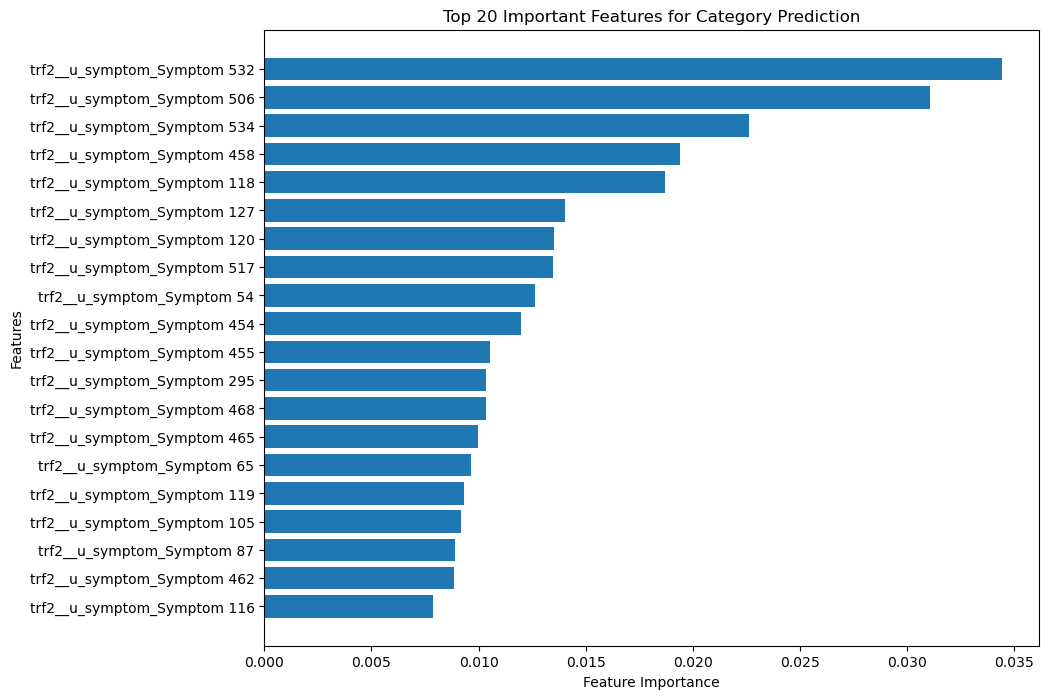

In [ ]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features for Category Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
feature_importance["Original_Feature"] = feature_importance["Feature"].apply(
    lambda x: x.split("__")[1].split("_")[0]
)

grouped_importance = (
    feature_importance
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print(grouped_importance)

Original_Feature
u            0.863397
location     0.121693
notify       0.003691
contact      0.003652
opened       0.003519
knowledge    0.002080
urgency      0.000746
impact       0.000697
is           0.000525
Name: Importance, dtype: float32


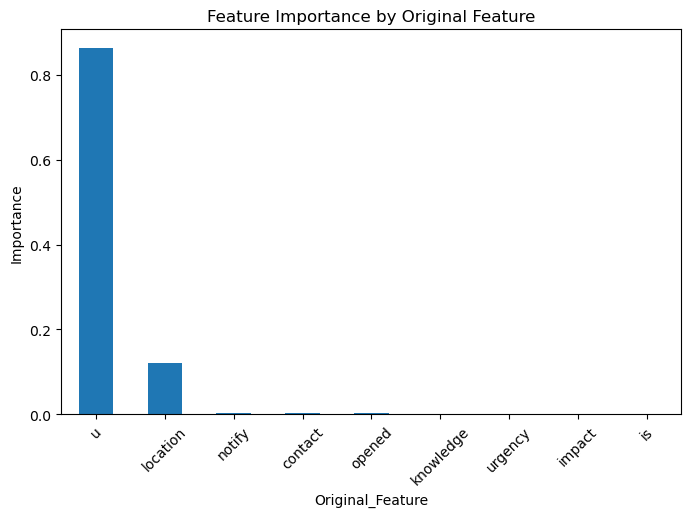

In [ ]:
import matplotlib.pyplot as plt

grouped_importance.plot(kind="bar", figsize=(8,5))
plt.title("Feature Importance by Original Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [ ]:
evaluate_model("Decision Tree", dt_pipeline, X_test, y_encoded_test)
evaluate_model("Random Forest", rf_pipeline, X_test, y_encoded_test)
evaluate_model("XGBoost", xgboost_pipeline, X_test, y_encoded_test)
evaluate_model("Tuned XGBoost",random_search.best_estimator_,X_test,y_encoded_test)

c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bharg\anaconda3\Lib\site-packag

In [ ]:
results

{'Decision Tree': {'Accuracy': 0.19086287247563904,
  'Precision': 0.049948650149265854,
  'Recall': 0.040310485195572385,
  'F1 Score': 0.03171109403340016},
 'Random Forest': {'Accuracy': 0.35235136280186413,
  'Precision': 0.4377334592056889,
  'Recall': 0.13164736638191532,
  'F1 Score': 0.16908599310711903},
 'XGBoost': {'Accuracy': 0.5430730122864003,
  'Precision': 0.7616514367226975,
  'Recall': 0.6785000502500541,
  'F1 Score': 0.6999070268954684},
 'Tuned XGBoost': {'Accuracy': 0.4992585792967095,
  'Precision': 0.7682590475737898,
  'Recall': 0.6459477288953376,
  'F1 Score': 0.6743032959888342}}

Saving the tuned and required preprocessing techniques used

Best Tuned Model 

In [150]:
import joblib

joblib.dump(
    xgboost_pipeline,
    r"D:\Enterprise_ITSM_AI\models_saved\category_prediction_pipeline.joblib"
)

['D:\\Enterprise_ITSM_AI\\models_saved\\category_prediction_pipeline.joblib']

Label Encoder

In [ ]:
joblib.dump(
    le,
    r"D:\Enterprise_ITSM_AI\models_saved\category_label_encoder.joblib"
)

['D:\\Enterprise_ITSM_AI\\models_saved\\category_label_encoder.joblib']

Best Hyperparameters

In [ ]:
import pandas as pd

best_params = pd.DataFrame([random_search.best_params_])

best_params.to_csv(
    r"D:\Enterprise_ITSM_AI\models_saved\category_best_parameters.csv",
    index=False
)

Model Evaluation Results

In [ ]:
results_df = pd.DataFrame(results).T

results_df.to_csv(
    r"D:\Enterprise_ITSM_AI\models_saved\category_model_results.csv"
)

In [74]:
feature_importance.to_csv(
    r"D:\Enterprise_ITSM_AI\models_saved\category_feature_importance.csv",
    index=False
)